In [28]:
include("../LiPoSID.jl")
using QuantumOptics
basis = NLevelBasis(2)
using LinearAlgebra
using Plots
#using StatsPlots
using Dates
using HDF5

using Statistics

#### Exact DMD works as follows

Lets collect *snapshots* of the state vectors of the system $\mathbf{x}_0, \mathbf{x}_1, \dots \mathbf{x}_N $ <br>
taken at some moments of time $t_0, t_1, \dots t_n$ <br>
and collected into matrices $X$ and $X'$:

$
X = 
\begin{bmatrix}
| & | & &| \\
x_0 & x_1 & \dots & x_{n-1} \\
| & | & &| \\
\end{bmatrix}, \quad
X' = 
\begin{bmatrix}
| & | & &| \\
x_1 & x_2 & \dots & x_n \\
| & | & &| \\
\end{bmatrix}
$

from the construction:

$X' = A X$

where $A$ could be estimated as follows:
$
\hat{A}  =  X' X^{+},
$

where $X^{+}$ denotes the Moore-Penrose pseudo inverse

If consider density matrix of the two level system it could be expressed with the elements of Bloch vector:

$
\rho  = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10}  & \rho_{11}
   \end{pmatrix} = \frac{1}{2}\begin{pmatrix} 1+ b_z& b_x-i b_y \\ b_x + i b_y  & 1-b_z
   \end{pmatrix}
$

$ \rho = \Omega \Omega^\dagger$


$
\sqrt{\rho} = \frac{1}{2} \left( \sqrt{1 + |\vec{b}|} \, I + \frac{\sqrt{1 - |\vec{b}|}}{|\vec{b}|} \, \vec{b} \cdot \vec{\sigma} \right)
$

$
\sqrt{\rho} = \begin{pmatrix} a & c + i d \\ c - i d & b \end{pmatrix}
$

Then we can find the matrix of the exact DMD liner model with the least squares:

$
  \tilde{A}^{(4D \ket{0} \ket{1} \ket{x} \ket{y})} = Y'_b Y_b^{+}, \quad \tilde{A}^{(4D \ket{0} \ket{1} \ket{x} \ket{y})}_c = \frac{\log (Y'_b Y_b^{+})}{\Delta t}
$

In [16]:
function bloch(ρ_list)
    # Pauli matricies
    σ = [ [0 1; 1 0], [0 -im; im 0], [1 0; 0 -1], [1 0; 0 1] ]

    bloch_vec = [
        convert.(Float64, [ ρ[1,2]+ρ[2,1],
                           (ρ[1,2]-ρ[2,1])*im,
                            ρ[1,1]-ρ[2,2]       ])
                for ρ in ρ_list]
    hcat(bloch_vec...)
end

function propagate(A, x0, steps)
    
    x = []
    push!(x, x0)

    @assert size(x0,1) == size(A,1) == size(A,2)

    for i=2:steps
        push!(x, A * x[end])
    end

    return x
end 

propagate (generic function with 1 method)

In [65]:
# Define the function to calculate the square root of the density matrix from Bloch vector components (3xN format)
function rho_from_sqrt_rho_bloch(bloch_vectors::Matrix{Float64})
    # Pauli matrices as a vector
    pauli_matrices = [
        [0.0 1.0; 1.0 0.0],   # sigma_x
        [0.0 -im; im 0.0],    # sigma_y
        [1.0 0.0; 0.0 -1.0]   # sigma_z
    ]
    
    # Define the 2x2 identity matrix explicitly
    I_matrix = Matrix{Complex{Float64}}(I(2))  # Explicitly create a 2x2 identity matrix

    # Calculate the magnitudes of the Bloch vectors (norm of each column vector)
    b_magnitudes = sqrt.(sum(bloch_vectors.^2, dims=1))

    # Check if any Bloch vector has magnitude > 1 and print a message
    if any(b_magnitudes .> 1)
        println("Warning: Some Bloch vectors have magnitudes greater than 1 and will be normalized.")
    end

    for (i, magnitude) in enumerate(b_magnitudes)
        if magnitude > 1
            bloch_vectors[:, i] .= bloch_vectors[:, i] ./ magnitude
        end
    end

    println(bloch_vectors)

    # Recompute magnitudes after normalization
    b_magnitudes = sqrt.(sum(bloch_vectors.^2, dims=1))

    # Precompute sqrt(1 + |b|) and sqrt(1 - |b|)
    sqrt_term_plus = sqrt.(1 .+ b_magnitudes)

    sqrt_term_minus = sqrt.(1 .- b_magnitudes)



    # Initialize an array to store the square root of the density matrices
    sqrt_rhos = Vector{Matrix{Complex{Float64}}}(undef, size(bloch_vectors, 2))
    rhos = Vector{Matrix{Complex{Float64}}}(undef, size(bloch_vectors, 2))

    # Compute the square root of the density matrix for each Bloch vector
    for i in 1:size(bloch_vectors, 2)
        # Compute the dot product of the Bloch vector with the Pauli matrices
        bloch_dot_sigma = bloch_vectors[1, i] * pauli_matrices[1] +
                          bloch_vectors[2, i] * pauli_matrices[2] +
                          bloch_vectors[3, i] * pauli_matrices[3]
        
        # Compute the square root of the density matrix for this Bloch vector
        sqrt_rhos[i] = 0.5 * (sqrt_term_plus[i] * I_matrix + sqrt_term_minus[i] * bloch_dot_sigma)

        rhos[i] = sqrt_rhos[i] * sqrt_rhos[i]'

    end

    return rhos
end

rho_from_sqrt_rho_bloch (generic function with 1 method)

In [66]:
parentdir = ".."
data_dir = parentdir*"/DATA/"
println(data_dir)

models_dir = parentdir*"/MODELS/"
tests_dir = "" #parentdir*"/TESTS/"

dodeca_files = ["D"*string(n) for n=1:10];
basis_files = ["B"*string(n) for n=1:4];

all_files = vcat(dodeca_files, basis_files)
test_states = dodeca_files;

evol_data_file_name = "../DATA/ALL_GAMMAS_B4_D10.h5"

γ = [ "0.079477",  "0.25133", "0.79477", "2.5133", "7.9477", "25.133",  "79.477", "251.33"]

../DATA/


8-element Vector{String}:
 "0.079477"
 "0.25133"
 "0.79477"
 "2.5133"
 "7.9477"
 "25.133"
 "79.477"
 "251.33"

In [106]:
data_dir = "../DATA/"

γᵢ = string(γ[6])

tᵍᵉˣʸ , ρᵍᵉˣʸ  = LiPoSID.read_GEXY_timeevolution(evol_data_file_name, γᵢ)

((Any[0.0, 5.0e-5, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003, 0.00035, 0.0004, 0.00045  …  0.1318, 0.13185, 0.1319, 0.13195, 0.132, 0.13205, 0.1321, 0.13215, 0.1322, 0.13225], Any[0.0, 5.0e-5, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003, 0.00035, 0.0004, 0.00045  …  0.16495, 0.165, 0.16505, 0.1651, 0.16515, 0.1652, 0.16525, 0.1653, 0.16535, 0.1654], Any[0.0, 5.0e-5, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003, 0.00035, 0.0004, 0.00045  …  0.1625, 0.16255, 0.1626, 0.16265, 0.1627, 0.16275, 0.1628, 0.16285, 0.1629, 0.16295], Any[0.0, 5.0e-5, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003, 0.00035, 0.0004, 0.00045  …  0.1092, 0.10925, 0.1093, 0.10935, 0.1094, 0.10945, 0.1095, 0.10955, 0.1096, 0.10965]), (Any[ComplexF64[1.0 + 0.0im 0.0 - 0.0im; 0.0 + 0.0im 0.0 + 0.0im], ComplexF64[0.999979900097 + 0.0im 0.0 - 0.0im; 0.0 + 0.0im 2.009990300000375e-5 + 0.0im], ComplexF64[0.99991967546 + 0.0im 0.0 - 0.0im; 0.0 + 0.0im 8.032453999995415e-5 + 0.0im], ComplexF64[0.999819550787 + 0.0im 0.0 - 0.0im; 0.0 + 0.0i

In [110]:
ρᵍ, ρᵉ, ρˣ, ρʸ = ρᵍᵉˣʸ
tᵍ, tᵉ, tˣ, tʸ = tᵍᵉˣʸ

lᵉ = length(ρᵉ); lᵍ = length(ρᵍ); lˣ = length(ρˣ); lʸ = length(ρʸ)
lᵐᵃˣ = min(lᵉ, lᵍ,  lˣ, lʸ)  #choose time limit by shortest series

tᵉᶠ = convert.(Float64, tᵉ); tᵍᶠ = convert.(Float64, tᵍ); 
tˣᶠ = convert.(Float64, tˣ); tʸᶠ = convert.(Float64, tʸ); 

t_list = [tᵉᶠ, tᵍᶠ, tˣᶠ, tʸᶠ]

Δt = tᵉᶠ[2] - tᵉᶠ[1]

bᵉ = bloch(ρᵉ[1:lᵐᵃˣ])
bᵍ = bloch(ρᵍ[1:lᵐᵃˣ])
bˣ = bloch(ρˣ[1:lᵐᵃˣ])
bʸ = bloch(ρʸ[1:lᵐᵃˣ])

Yᵉ = [bᵉ; sum(bᵉ .^ 2, dims=1)] #; ones(lᵐᵃˣ)']
Yᵍ = [bᵍ; sum(bᵍ .^ 2, dims=1)] #; ones(lᵐᵃˣ)']
Yˣ = [bˣ; sum(bˣ .^ 2, dims=1)] #; ones(lᵐᵃˣ)']
Yʸ = [bʸ; sum(bʸ .^ 2, dims=1)] #; ones(lᵐᵃˣ)']

Yᵉ⁻ = Yᵉ[:,1:end-1]; Yᵉ⁺ = Yᵉ[:,2:end]
Yᵍ⁻ = Yᵍ[:,1:end-1]; Yᵍ⁺ = Yᵍ[:,2:end]
Yˣ⁻ = Yˣ[:,1:end-1]; Yˣ⁺ = Yˣ[:,2:end]
Yʸ⁻ = Yᵉ[:,1:end-1]; Yʸ⁺ = Yᵉ[:,2:end]

Y⁻ = hcat(Yᵉ⁻, Yᵍ⁻, Yˣ⁻, Yʸ⁻)
Y⁺ = hcat(Yᵉ⁺, Yᵍ⁺, Yˣ⁺, Yʸ⁺)

A⁴ᴰ = Y⁺ * pinv(Y⁻) # Direct DMD estimation

A⁴ᴰc = log(A⁴ᴰ)/Δt

bᵉ⁴ᴰ = hcat(propagate(A⁴ᴰ, Yᵉ[:,1], lᵐᵃˣ)...)[1:3,:]  
bᵍ⁴ᴰ = hcat(propagate(A⁴ᴰ, Yᵍ[:,1], lᵐᵃˣ)...)[1:3,:] 
bˣ⁴ᴰ = hcat(propagate(A⁴ᴰ, Yˣ[:,1], lᵐᵃˣ)...)[1:3,:] 
bʸ⁴ᴰ = hcat(propagate(A⁴ᴰ, Yʸ[:,1], lᵐᵃˣ)...)[1:3,:] 

ρᵉ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵉ⁴ᴰ) 
ρᵍ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵍ⁴ᴰ)
ρˣ⁴ᴰ = LiPoSID.rho_series_from_bloch(bˣ⁴ᴰ)
ρʸ⁴ᴰ = LiPoSID.rho_series_from_bloch(bʸ⁴ᴰ)

F = LiPoSID.fidelity_series(basis, ρˣ, ρˣ⁴ᴰ)


2194-element Vector{Float64}:
 0.9999999999999997
 1.0000000411045216
 1.0000001278185262
 1.0000002842139708
 1.0000004998279521
 1.0000007722873983
 1.000001099257137
 1.0000014782992193
 1.0000019068728607
 1.0000023823342978
 ⋮
 0.998407463917174
 0.9984019397512784
 0.9983964094390771
 0.9983908730048409
 0.9983853304252306
 0.9983797816295661
 0.9983742265000445
 0.9983686648731147
 0.9983630965404751

In [111]:
Yᵉ = [bᵉ; ones(lᵐᵃˣ)']
Yᵍ = [bᵍ; ones(lᵐᵃˣ)']
Yˣ = [bˣ; ones(lᵐᵃˣ)']
Yʸ = [bʸ; ones(lᵐᵃˣ)']

Yᵉ⁻ = Yᵉ[:,1:end-1]; Yᵉ⁺ = Yᵉ[:,2:end]
Yᵍ⁻ = Yᵍ[:,1:end-1]; Yᵍ⁺ = Yᵍ[:,2:end]
Yˣ⁻ = Yˣ[:,1:end-1]; Yˣ⁺ = Yˣ[:,2:end]
Yʸ⁻ = Yᵉ[:,1:end-1]; Yʸ⁺ = Yᵉ[:,2:end]

Y⁻ = hcat(Yᵉ⁻, Yᵍ⁻, Yˣ⁻, Yʸ⁻)
Y⁺ = hcat(Yᵉ⁺, Yᵍ⁺, Yˣ⁺, Yʸ⁺)

A⁴ᴰ = Y⁺ * pinv(Y⁻) # Direct DMD estimation

A⁴ᴰc = log(A⁴ᴰ)/Δt

bᵉ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bᵉ[:,1]...,1], lᵐᵃˣ)...)[1:3,:] 
bᵍ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bᵍ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]
bˣ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bˣ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]
bʸ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bʸ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]

ρᵉ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵉ⁴ᴰ) 
ρᵍ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵍ⁴ᴰ)
ρˣ⁴ᴰ = LiPoSID.rho_series_from_bloch(bˣ⁴ᴰ)
ρʸ⁴ᴰ = LiPoSID.rho_series_from_bloch(bʸ⁴ᴰ)

F = LiPoSID.fidelity_series(basis, ρˣ, ρˣ⁴ᴰ)

2194-element Vector{Float64}:
 0.9999999999999997
 1.0000000317172648
 1.0000001344040803
 1.0000002795071425
 1.0000004915156357
 1.000000759380787
 1.0000010808076765
 1.0000014534023478
 1.0000018746739638
 1.0000023420499327
 ⋮
 0.9990602488308143
 0.9990576217936935
 0.9990549955510167
 0.9990523701403983
 0.9990497455587951
 0.9990471217623087
 0.9990444986667133
 0.9990418761482052
 0.9990392540444117

In [127]:
ρₛᵣₜᵍ = sqrt.(ρᵍ)
ρₛᵣₜᵉ = sqrt.(ρᵉ)
ρₛᵣₜˣ = sqrt.(ρˣ)
ρₛᵣₜʸ = sqrt.(ρʸ)

Yˣ = hcat([vec.(real.(ρₛᵣₜˣ))[i]...; vec.(imag.(ρₛᵣₜˣ))[i]...] for i in 1:length(ρₛᵣₜˣ))

1×1 Matrix{Base.Generator{UnitRange{Int64}, var"#85#86"}}:
 Base.Generator{UnitRange{Int64}, var"#85#86"}(var"#85#86"(), 1:3260)

In [135]:
Yᵍₛᵣₜ = hcat([[vec.(real.(ρₛᵣₜᵍ))[i]...; vec.(imag.(ρₛᵣₜᵍ))[i]...] for i in 1:length(ρₛᵣₜᵍ)]...)
Yᵉₛᵣₜ = hcat([[vec.(real.(ρₛᵣₜᵉ))[i]...; vec.(imag.(ρₛᵣₜᵉ))[i]...] for i in 1:length(ρₛᵣₜᵉ)]...)
Yˣₛᵣₜ = hcat([[vec.(real.(ρₛᵣₜˣ))[i]...; vec.(imag.(ρₛᵣₜˣ))[i]...] for i in 1:length(ρₛᵣₜˣ)]...)
Yʸₛᵣₜ = hcat([[vec.(real.(ρₛᵣₜʸ))[i]...; vec.(imag.(ρₛᵣₜʸ))[i]...] for i in 1:length(ρₛᵣₜʸ)]...)

Yᵉ⁻ₛᵣₜ = Yᵉₛᵣₜ[:,1:end-1]; Yᵉ⁺ₛᵣₜ = Yᵉₛᵣₜ[:,2:end]
Yᵍ⁻ₛᵣₜ = Yᵍₛᵣₜ[:,1:end-1]; Yᵍ⁺ₛᵣₜ = Yᵍₛᵣₜ[:,2:end]
Yˣ⁻ₛᵣₜ = Yˣₛᵣₜ[:,1:end-1]; Yˣ⁺ₛᵣₜ = Yˣₛᵣₜ[:,2:end]
Yʸ⁻ₛᵣₜ = Yᵉₛᵣₜ[:,1:end-1]; Yʸ⁺ₛᵣₜ = Yᵉₛᵣₜ[:,2:end]

Y⁻ₛᵣₜ = hcat(Yᵉ⁻ₛᵣₜ, Yᵍ⁻ₛᵣₜ, Yˣ⁻ₛᵣₜ, Yʸ⁻ₛᵣₜ)
Y⁺ₛᵣₜ = hcat(Yᵉ⁺ₛᵣₜ, Yᵍ⁺ₛᵣₜ, Yˣ⁺ₛᵣₜ, Yʸ⁺ₛᵣₜ)


8×12520 Matrix{Float64}:
  0.00448334   0.00896277   0.0134344  …   0.884321     0.884324
  0.0          0.0          0.0            1.96228e-7   1.95332e-7
  0.0          0.0          0.0            1.96228e-7   1.95332e-7
  0.99999      0.99996      0.99991        0.46688      0.466874
  0.0          0.0          0.0            0.0          0.0
 -0.0         -0.0         -0.0        …   7.00356e-7   7.27387e-7
  0.0          0.0          0.0           -7.00356e-7  -7.27387e-7
  0.0          0.0          0.0            0.0          0.0

In [119]:
length(ρₛᵣₜˣ)

3260

In [95]:
ρ_true = ρˣ
ρ_sqrt = sqrt.(ρ_true)
ρ_renew = [ρ_sqrt[i] * ρ_sqrt[i]' for i in 1:length(ρ_sqrt)]
minimum(LiPoSID.fidelity_series(basis, ρ_true, ρ_renew))

0.9999999999999876

In [88]:
ρₛᵣₜˣ = sqrt.(ρˣ)

2×2 Matrix{ComplexF64}:
  0.501058+0.0im       0.0320328-0.497881im
 0.0320328+0.497881im   0.498942+0.0im

In [82]:
ₛᵣₜ 

Base.Meta.ParseError: ParseError:
# Error @ /home/zah/github/quantum-open-systems-polynomial-sid/LSID/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X34sZmlsZQ==.jl:1:47
LiPoSID.fidelity_series(basis, ρˣ, sqrt.(ρˣ) *. sqrt.(ρˣ)')
#                                             ╙ ── invalid identifier

In [23]:
Yʸ

4×1256 Matrix{Float64}:
  0.995763    0.901963    0.585314   …  0.022742  -0.156216  -0.296365
 -0.0609392   0.42611     0.807041      0.365901   0.331141   0.214759
  0.00211579  0.00362047  0.0053365     0.86457    0.864781   0.864987
  0.995262    0.995121    0.993936      0.881882   0.881904   0.882157

In [24]:
bʸ⁴ᴰ

4×1256 Matrix{Float64}:
  0.995763    0.901968    0.585321    …  0.0227295  -0.15686   -0.297382
 -0.0609392   0.426114    0.80704        0.367245    0.332218   0.215109
  0.00211579  0.00406501  0.00600753     0.594833    0.59503    0.59523
  0.995262    0.992561    0.989876       0.584481    0.584661   0.584844

In [74]:
ρˣ[2]

2×2 Matrix{ComplexF64}:
   0.50181+0.0im      -0.211591-0.45098im
 -0.211591+0.45098im    0.49819+0.0im

In [75]:
ρˣ_from_root = rho_from_sqrt_rho_bloch(bˣ)
ρˣ_from_root[2]

[0.064065622972 -0.423182112464 -0.805027825978 -0.987231470708 -0.925062204682 -0.634279096248 -0.187138786452 0.305559315064 0.721928059732 0.959145643576 0.958846955012 0.721483009248 0.306116356364 -0.184274880772 -0.628327043176 -0.916326102232 -0.977315120438 -0.796575697404 -0.419177868298 0.06125803758 0.525785352548 0.85957936942 0.980320454518 0.858494992706 0.524608387734 0.061547769552 -0.415994556998 -0.789927868272 -0.9679653109 -0.906400034582 -0.620833960126 -0.182226403614 0.30073816293 0.708581008756 0.940586225746 0.939672164824 0.706434653252 0.298908416162 -0.181872757404 -0.616924113276 -0.898756009142 -0.957931666592 -0.780174091524 -0.40980842285 0.061290042704 0.516486874574 0.84326427453 0.961033732754 0.841009888786 0.513245040404 0.059105903084 -0.408925395492 -0.77511059529 -0.94907565897 -0.888114757728 -0.607672952726 -0.177435456322 0.295987826828 0.695479040598 0.92238524197 0.920880272554 0.691698884542 0.291865552028 -0.179493717418 -0.60572635189 -0.

2×2 Matrix{ComplexF64}:
   0.500149+0.0im       -0.0181681-0.038723im
 -0.0181681+0.038723im    0.499838+0.0im

In [76]:
F = LiPoSID.fidelity_series(basis, ρˣ, ρˣ_from_root)

1256-element Vector{Float64}:
 0.7521552386032857
 0.7651032248157399
 0.7719071176345849
 0.773583140592309
 0.773770336935312
 0.7767922131591174
 0.7836377171934917
 0.7912738688812979
 0.7964178846104656
 0.7981477866992321
 ⋮
 0.9016068950865873
 0.9013926948889484
 0.9013467110023536
 0.9013929489347522
 0.9013761477709055
 0.901217062412774
 0.9009842460950714
 0.9008167434353483
 0.9007835141868374

In [2]:
function propagate(A, x0, steps)
    
    x = []
    push!(x, x0)

    @assert size(x0,1) == size(A,1) == size(A,2)

    for i=2:steps
        push!(x, A * x[end])
    end

    return x
end 

function bloch(ρ_list)
    # Pauli matricies
    σ = [ [0 1; 1 0], [0 -im; im 0], [1 0; 0 -1], [1 0; 0 1] ]

    bloch_vec = [
        convert.(Float64, [ ρ[1,2]+ρ[2,1],
                           (ρ[1,2]-ρ[2,1])*im,
                            ρ[1,1]-ρ[2,2]       ])
                for ρ in ρ_list]
    hcat(bloch_vec...)
end

function propagate_rho_O1XY(ρ₀, ρᵉᵍˣʸ, steps)

    #hcat(vec[ρᵢ] for ρᵢ in ρᵉᵍˣʸ)

    kᵉᵍˣʸ = hcat([vec(ρᵢ[1]) for ρᵢ in ρᵉᵍˣʸ]...)\vec(ρ₀)

    kᵉ, kᵍ, kˣ, kʸ = kᵉᵍˣʸ              
    ρᵉ, ρᵍ, ρˣ, ρʸ = ρᵉᵍˣʸ

    steps = min(length(ρᵉ), length(ρᵍ), length(ρˣ), length(ρʸ))

    ρ = kᵉ * ρᵉ[1:steps] + kᵍ * ρᵍ[1:steps] + kˣ * ρˣ[1:steps] + kʸ * ρʸ[1:steps]

    return ρ
end 

propagate_rho_O1XY (generic function with 1 method)

In [17]:
function SBvs4DBlochDMD_basis(γᵢ)

    data_dir = "../DATA/"

    γᵢ = string(γᵢ)

    tᵍᵉˣʸ , ρᵍᵉˣʸ  = LiPoSID.read_GEXY_timeevolution(evol_data_file_name, γᵢ)

    ρᵍ, ρᵉ, ρˣ, ρʸ = ρᵍᵉˣʸ
    tᵍ, tᵉ, tˣ, tʸ = tᵍᵉˣʸ

    lᵉ = length(ρᵉ); lᵍ = length(ρᵍ); lˣ = length(ρˣ); lʸ = length(ρʸ)
    lᵐᵃˣ = min(lᵉ, lᵍ,  lˣ, lʸ)  #choose time limit by shortest series

    bᵉ = bloch(ρᵉ[1:lᵐᵃˣ])
    bᵍ = bloch(ρᵍ[1:lᵐᵃˣ])
    bˣ = bloch(ρˣ[1:lᵐᵃˣ])
    bʸ = bloch(ρʸ[1:lᵐᵃˣ])

    

    tᵉᶠ = convert.(Float64, tᵉ); tᵍᶠ = convert.(Float64, tᵍ); 
    tˣᶠ = convert.(Float64, tˣ); tʸᶠ = convert.(Float64, tʸ); 

    t_list = [tᵉᶠ, tᵍᶠ, tˣᶠ, tʸᶠ]

    Δt = tᵉᶠ[2] - tᵉᶠ[1]

    t = t_list[argmin(length(tⁱ) for tⁱ in t_list)]
    
    ρˢᵇ = [ρᵉ[1:lᵐᵃˣ], ρᵍ[1:lᵐᵃˣ], ρˣ[1:lᵐᵃˣ], ρʸ[1:lᵐᵃˣ]]

    Yᵉ = [bᵉ; ones(lᵐᵃˣ)']
    Yᵍ = [bᵍ; ones(lᵐᵃˣ)']
    Yˣ = [bˣ; ones(lᵐᵃˣ)']
    Yʸ = [bʸ; ones(lᵐᵃˣ)']

    Yᵉ⁻ = Yᵉ[:,1:end-1]; Yᵉ⁺ = Yᵉ[:,2:end]
    Yᵍ⁻ = Yᵍ[:,1:end-1]; Yᵍ⁺ = Yᵍ[:,2:end]
    Yˣ⁻ = Yˣ[:,1:end-1]; Yˣ⁺ = Yˣ[:,2:end]
    Yʸ⁻ = Yᵉ[:,1:end-1]; Yʸ⁺ = Yᵉ[:,2:end]

    Y⁻ = hcat(Yᵉ⁻, Yᵍ⁻, Yˣ⁻, Yʸ⁻)
    Y⁺ = hcat(Yᵉ⁺, Yᵍ⁺, Yˣ⁺, Yʸ⁺)

    A⁴ᴰ = Y⁺ * pinv(Y⁻) # Direct DMD estimation

    A⁴ᴰc = log(A⁴ᴰ)/Δt
    
    bᵉ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bᵉ[:,1]...,1], lᵐᵃˣ)...)[1:3,:] 
    bᵍ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bᵍ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]
    bˣ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bˣ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]
    bʸ⁴ᴰ = hcat(propagate(A⁴ᴰ, [bʸ[:,1]...,1], lᵐᵃˣ)...)[1:3,:]

    ρᵉ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵉ⁴ᴰ) 
    ρᵍ⁴ᴰ = LiPoSID.rho_series_from_bloch(bᵍ⁴ᴰ)
    ρˣ⁴ᴰ = LiPoSID.rho_series_from_bloch(bˣ⁴ᴰ)
    ρʸ⁴ᴰ = LiPoSID.rho_series_from_bloch(bʸ⁴ᴰ)

    ρᴮ⁴ᴰᴹᴰ = [ρᵉ⁴ᴰ, ρᵍ⁴ᴰ, ρˣ⁴ᴰ, ρʸ⁴ᴰ]

    Δt = t[2] - t[1]

    
    return ρˢᵇ, ρᴮ⁴ᴰᴹᴰ, t[1:lᵐᵃˣ], A⁴ᴰc

end

SBvs4DBlochDMD_basis (generic function with 1 method)

In [11]:
parentdir = ".."
data_dir = parentdir*"/DATA/"
println(data_dir)

models_dir = parentdir*"/MODELS/"
tests_dir = "" #parentdir*"/TESTS/"

dodeca_files = ["D"*string(n) for n=1:10];
basis_files = ["B"*string(n) for n=1:4];

all_files = vcat(dodeca_files, basis_files)
test_states = dodeca_files;

evol_data_file_name = "../DATA/ALL_GAMMAS_B4_D10.h5"

../DATA/


"../DATA/ALL_GAMMAS_B4_D10.h5"

In [23]:
date_and_time_string =  string(Dates.format(now(), "yyyy-u-dd_at_HH-MM"))

tests_data_file_name = "DMD-Bloch4D_SB_trn4_tst20_"*date_and_time_string * ".h5"

println(tests_data_file_name)

γ = [ "0.079477",  "0.25133", "0.79477", "2.5133", "7.9477", "25.133",  "79.477", "251.33"]

#γ = ["0.0", "0.079477",  "0.25133", "0.79477", "2.5133", "7.9477", "25.133",  "79.477", "251.33"]

FminGammas = []
FmedianGammas = []
FmeanGammas = []
PositiveEvals = []

for γᵢ in  γ

    ρˢᵇ, ρᴮ⁴ᴰᴹᴰ, t, A⁴ᴰc = SBvs4DBlochDMD_basis(γᵢ)

    evals, evecs = eigen(A⁴ᴰc)

    if isempty(evals[real.(evals).>0])
        maxposeval = 0
    else
        maxposeval = maximum(real.(evals[real.(evals).>0]))
    end

    push!(PositiveEvals, maxposeval)

    h5open(tests_dir*tests_data_file_name,"cw") do fid
        γ_group = create_group(fid, γᵢ) # create coupling group
        γ_group["Ac"] = A⁴ᴰc
        γ_group["max_pos_eigenval"] = maxposeval
    end 

    println()
    println("γᵢ = ", γᵢ)

    ρᵉˢᵇ, ρᵍˢᵇ, ρˣˢᵇ, ρʸˢᵇ = ρˢᵇ
    ρᵉᴮ⁴ᴰᴹᴰ, ρᵍᴮ⁴ᴰᴹᴰ, ρˣᴮ⁴ᴰᴹᴰ, ρʸᴮ⁴ᴰᴹᴰ = ρᴮ⁴ᴰᴹᴰ

    FminStates = []
    FmedianStates = []
    FmeanStates = []

    for state in test_states # loop over initial states
        
        print(state*" ")

        tᵗˢᵗ, ρᵗˢᵗ = LiPoSID.read_timeevolution(evol_data_file_name, state, γᵢ)

        if length(tᵗˢᵗ) > 1200 end_tst = 1200 else end_tst = length(tᵗˢᵗ) end

        tᵗˢᵗᶠ = convert.(Float64, tᵗˢᵗ)

        steps = min(end_tst, length(t))

        ρᵗˢᵗᴮ⁴ᴰᴹᴰ =  propagate_rho_O1XY(ρᵗˢᵗ[1], ρᴮ⁴ᴰᴹᴰ, steps)

        Fᴮ⁴ᴰᴹᴰ = LiPoSID.fidelity_series(basis, ρᵗˢᵗᴮ⁴ᴰᴹᴰ[1:steps], ρᵗˢᵗ[1:steps])

        h5open(tests_dir*tests_data_file_name,"cw") do fid
            γ_group = open_group(fid, γᵢ) # create coupling group
            state_group = create_group(γ_group, state) # create coupling group
            state_group["Fidelity"] = convert.(Float64, Fᴮ⁴ᴰᴹᴰ)
            state_group["time"] = convert.(Float64, tᵗˢᵗ[1:steps]) 
        end

        FminState = minimum(Fᴮ⁴ᴰᴹᴰ)
        FmedianState = mean(Fᴮ⁴ᴰᴹᴰ)
        FmeanState = mean(Fᴮ⁴ᴰᴹᴰ)
        
        push!(FminStates, FminState)
        push!(FmedianStates, FmedianState)
        push!(FmeanStates, FmeanState)

    end

        # Calculate the mean
        F_mean_value = mean(FmeanStates)

        # Calculate the median
        F_median_value = median(FmedianStates)
    
        # Calculate the min
        F_min_value = minimum(FminStates)
    
        push!(FminGammas, F_min_value)
        push!(FmedianGammas, F_median_value)
        push!(FmeanGammas, F_mean_value)
    
        println("Median fidelity for "*γᵢ*": ", F_median_value)
        
end

DMD-Bloch4D_SB_trn4_tst20_2024-Sep-16_at_14-41.h5

γᵢ = 0.079477
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 0.079477: 0.999999764502224

γᵢ = 0.25133
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 0.25133: 0.9999998514776614

γᵢ = 0.79477
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 0.79477: 0.9999990599814211

γᵢ = 2.5133
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 2.5133: 0.9999938701993294

γᵢ = 7.9477
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 7.9477: 0.9998870079908934

γᵢ = 25.133
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 25.133: 0.9958273667833694

γᵢ = 79.477
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 79.477: 0.997920753924531

γᵢ = 251.33
D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 Median fidelity for 251.33: 0.9199199656994039


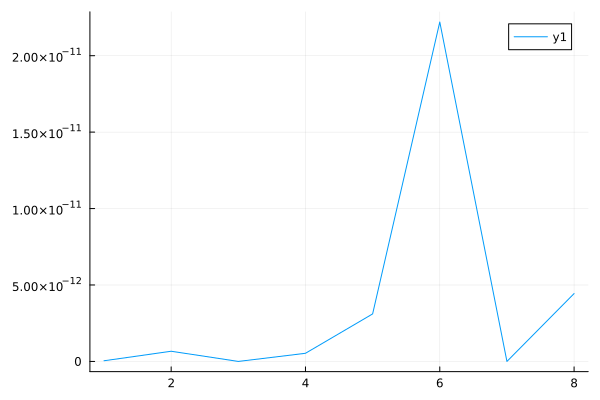

In [24]:
plot(PositiveEvals)

In [25]:
using PyCall

# Import the pickle module from Python
pickle = pyimport("pickle")

# Use Python's built-in open function to open the file in binary write mode
pyopen = pyimport("builtins").open

# Open a file in write-binary mode using Python's open function
file = pyopen("PositiveEigenVals.pkl", "wb")

# Use pickle's dump function to save the array
pickle.dump(PositiveEvals, file) #NaN16

# Close the file
file.close()